<a href="https://colab.research.google.com/github/sbht04/ai-agents/blob/main/Multi_Agents_Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multi-Agent Content Writer — LangGraph Assignment**

## **Problem Statement**

Build a **multi-agent system** using LangGraph that acts as a smart content assistant. The system should have a **router** that reads the user's request and sends it to the right agent:

- **SEO Blog Writer** — writes long-form blog posts, uses research & keyword tools autonomously
- **X/Twitter Writer** — writes short tweets (<280 chars), uses trending topic tools autonomously
- **General Handler** — answers everything else (greetings, questions, etc.) using conversation memory

The system must support **tool-calling loops** (agent calls a tool → gets result → decides to call another tool or finish) and **persistence** (remembers past conversations using a checkpointer so follow-up questions like "what was my last request?" work).

### Architecture

```
                 ┌→ SEO Blog Writer ↔ tools (loop)
User → Router ───┼→ X/Twitter Writer ↔ tools (loop)
                 └→ General Handler → END
```

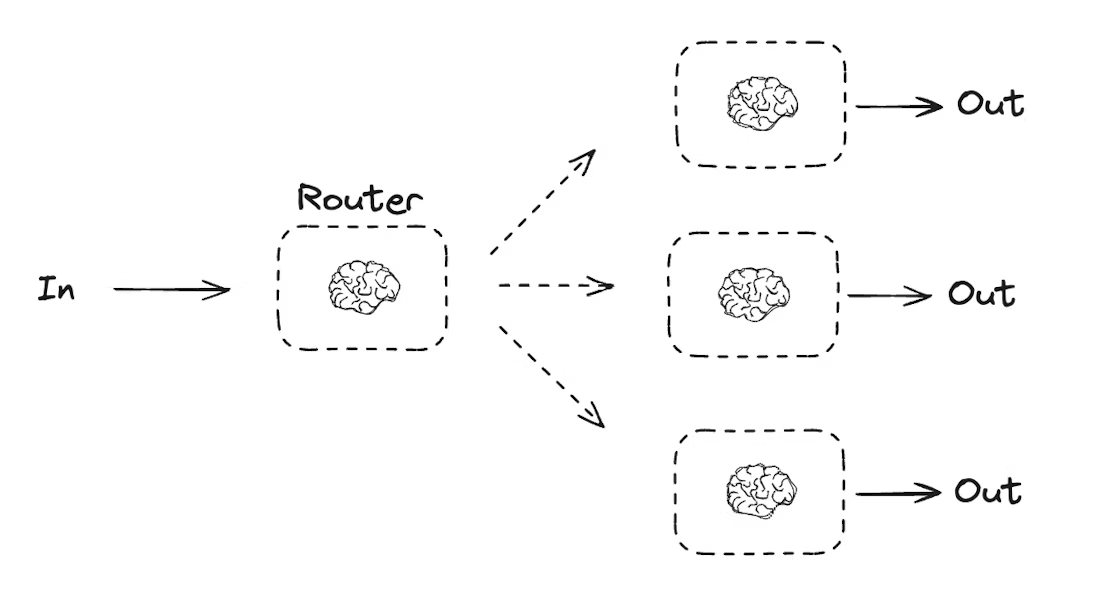




## **💡Tips**

You don't have to use mock data — you can make your tools actually work!

`research_tool` → Use a Deep Research agent (Tavily Deep Search, Perplexity API) to fetch real articles, papers, and references. These calls are heavier and costlier, so design your agent to call this once or twice for in-depth content gathering — not repeatedly.

---


`internet_search_tool` → Use SerpAPI, Google Custom Search API, or Tavily basic search for quick lookups like SEO keywords, trending topics, and hashtags. These are lighter and cheaper, so it's okay if the agent calls this multiple times.


---


**Think about cost-efficiency:** In your agent's system prompt, guide it on when to use which tool — e.g., "Use research_tool first to gather deep content, then use internet_search_tool for SEO keywords and trends. Avoid calling research_tool always." This is how real-world agents are designed — you control tool usage through smart prompting, not just by giving access.


## **Steps**




### Step 1: Setup
Install `langgraph`, `langchain`, `langchain-openai`. Configure your LLM.


In [ ]:
pip install langgraph langchain langchain-openai

In [ ]:
# Import API Keys

import getpass
import os
from google.colab import userdata

try:
    api_key_from_secrets = userdata.get("OPENAI_API_KEY")
    os.environ["OPENAI_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

In [ ]:
from langchain_openai import OpenAI as LangchainOpenAI
import os
from google.colab import userdata
import getpass
import openai

# Ensure API key is set before initializing OpenAI client
try:
    api_key_from_secrets = userdata.get("OPENAI_API_KEY")
    os.environ["OPENAI_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

# Create a lightweight client instance for LangChain
llm_client = LangchainOpenAI()

# Create an OpenAI client specifically for listing models
openai_client = openai.OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

# Fetch and print available models
models = openai_client.models.list()

print("Available models:")
for m in models.data:
    print("-", m.id)

Enter your OpenAI API key: ··········
Available models:
- text-embedding-3-small
- text-embedding-3-large
- gpt-4o
- gpt-4o-mini
- gpt-5
- text-embedding-ada-002


In [ ]:
# Chat Model

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5",
    # stream_usage=True,
    temperature=0.2,
    # max_tokens=None,
    # timeout=None,
    # reasoning_effort="low",
    # max_retries=2,
    # api_key="...",  # If you prefer to pass api key in directly
    # base_url="...",
    # organization="...",
    # other params...
)

In [ ]:
test_msg = llm.invoke("What is Mlachine Learning? Explain with the help of an example.")

# Print in Readable Format
print(test_msg.text)

Machine Learning (ML) is a way of programming computers to learn patterns from data and make predictions or decisions without being explicitly told the rules. Instead of writing if–then rules, you give the system examples, and it learns the relationship between inputs and outputs.

Simple example: Email spam filter
- Goal: Automatically label incoming emails as “spam” or “not spam.”
- Data: Thousands of past emails, each labeled spam/not spam.
- Features: Words used, number of links, sender domain, presence of certain phrases, etc.
- Training: Use a learning algorithm (e.g., Naive Bayes, logistic regression) to find patterns that distinguish spam from non-spam based on the features.
- Prediction: For a new email, the model calculates the probability it’s spam and assigns a label.
- Improvement: As users mark emails correctly or incorrectly, those new examples help retrain and improve the model.

Why this is useful: It adapts to new spam tactics over time without engineers hand-coding n

### Step 2: Define State
Create a shared `TypedDict` with: `user_input`, `route`, `output`, `messages`. Use `add_messages` reducer on messages.



In [ ]:
from typing import TypedDict, List, Optional
from langgraph.graph import add_messages

# -----------------------------------------
# Shared State for All Agents
# -----------------------------------------
class AgentState(TypedDict):
    user_input: str                     # Raw user request
    route: Optional[str]                # "seo", "twitter", "general"
    output: Optional[str]               # Final answer from the selected agent
    messages: List[dict]                # Conversation history


# -----------------------------------------
# Reducer: Append messages to history
# -----------------------------------------
# This tells LangGraph how to merge new messages into the state.
# Every agent can add messages, and LangGraph will append them.
messages = add_messages("messages")


### Step 3: Router Node
Classifies input into `seo_blog_writer` / `x_blog_writer` / `general`. Returns only one word. Also persists user input into messages.



In [ ]:
# Write your code here

### Step 4: Tools
Define 2 tools with `@tool`: `research_tool` (finds articles/references) and `internet_search_tool` (finds SEO keywords/trending topics). Mock responses are fine.



In [ ]:
# Write your code here

### Step 5: SEO Blog Writer
Bind both tools to LLM. Agent checks state messages for tool loop continuation. Writes structured blog with headings and CTA.



In [ ]:
# Write your code here

### Step 6: X/Twitter Writer
Bind only `internet_search_tool`. Same loop pattern. Writes short posts with emojis and hashtags.



In [ ]:
# Write your code here

### Step 7: General Handler
Uses full message history from state to answer general queries with context. Saves both user and AI messages for persistence.



In [ ]:
# Write your code here

### Step 8: Build Graph
Add all nodes. Router → 3-way conditional edges. Agent ↔ tool loops using `should_continue` functions. General → END.



In [ ]:
# Write your code here

### Step 9: Persistence
Add `MemorySaver` checkpointer. Compile graph. Pass `thread_id` in config on every call.


In [ ]:
# Write your code here

### Step 10: Test
- Test all 3 routes work correctly

In [ ]:
# Write your code here